### Consumer Demand Model

In [6]:
!pip install -r requirements-est.txt
%pip install CFEDemands
# %pip install eep153_tools

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
x = pd.read_csv('data/Panama - Food Expenditures (2003).csv')
p = pd.read_csv('data/Panama - Food Prices (2003).csv')
d = pd.read_csv('data/Panama - Household Characteristics (2003).csv')
import numpy as np

In [8]:
Panama_data = '1tYmqzz4VqM5rd4aeO6zB4wL9ADcoTdvTPKZF5zgX7a4'

In [11]:
x = x.set_index(['i','t','m','j']).squeeze()

# Compute medians of prices for particular time, place and unit
p = p.groupby(['t','m','j','u']).median()

# Just keep metric units
p = p.xs('kg',level="u").squeeze().unstack('j')

# Get intersection of goods we have prices *and* expenditures for:
jidx = p.columns.intersection(x.index.levels[-1])

# Drop prices for goods we don't have expenditures for
p = p[jidx].T

# Household characteristics
d.columns.name = 'k'

# Fill blanks with zeros
d = d.replace(np.nan,0)

# Expenditures x may have duplicate columns
x = x.T.groupby(['i','t','m','j']).sum()
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

In [13]:
d.head()

,,k,men,women,girls,boys,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
1997125,1997,Herrera,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1.098612
1997160,1997,Herrera,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1.098612
1997170,1997,Bocas Del Toro,1,1,4,3,1,2,1,0,0,1,1,1,0,0,0,1,1,0,2.197225
1997177,1997,Bocas Del Toro,1,4,5,9,2,1,4,1,1,3,2,0,0,2,0,2,1,0,2.944439
1997178,1997,Bocas Del Toro,2,2,2,1,0,0,0,1,1,0,0,1,2,0,0,1,0,1,1.945910


In [14]:
y.head()

i        t     m      j             
2003199  2003  Colón  Aceite Vegetal    0.559616
                      Ahí Verde        -1.386294
                      Apio             -1.897120
                      Arroz             1.266948
                      Azúcar            0.438255
Name: Expenditure, dtype: float64

In [15]:
from cfe import Regression

result = Regression(y=y,d=d)

In [16]:
result.predicted_expenditures()

i         t     m        j                       
2003199   2003  Colón    Aceite Vegetal              2.606201
                         Ajo                         0.611317
                         Arroz                       5.702980
                         Azúcar                      1.648507
                         Café Y Té                   1.540986
                                                       ...   
20039596  2003  Herrera  Sal                         0.431861
                         Sardina Y Atún              2.184535
                         Sodas, Refrescos Y Jugos    3.889362
                         Tomate                      1.528868
                         Yuca                        0.678699
Length: 195294, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

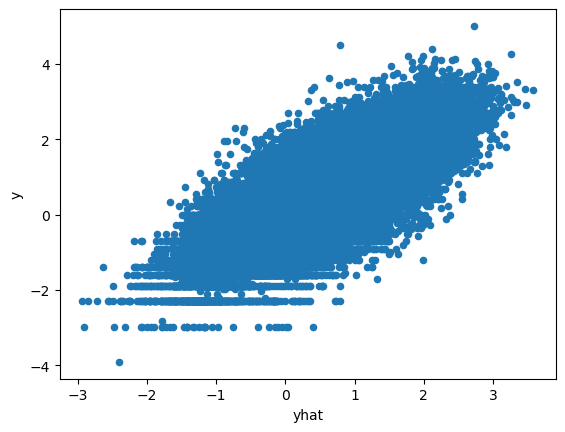

In [17]:
%matplotlib inline
df = pd.DataFrame({'y':y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')